In [127]:
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

In [156]:
DLATENT = '/Users/user/data/research/proton-deuteron/latentvectors/d_latent.npy'
PLATENT = '/Users/user/data/research/proton-deuteron/latentvectors/p_latent.npy'

HANDPICKED = '/Users/user/data/research/proton-deuteron/ssvd/handpicked_d.pkl'
CANDIDATES = '/Users/user/data/research/proton-deuteron/ssvd/deuteron_candidates_clean.pkl'
PROTONS = '/Users/user/data/research/proton-deuteron/ssvd/proton_candidates.pkl'

h = pd.read_pickle(HANDPICKED)
c = pd.read_pickle(CANDIDATES)

deuterons = pd.concat([h, c], ignore_index=True)

MOMENTUM_TOF = '/Users/user/data/research/proton-deuteron/bruno/root/momentum_tof.csv'
df = pd.read_csv(MOMENTUM_TOF)

deuterons = pd.merge(deuterons,
                     df,
                     on=['run', 'subrun', 'event'],
                     how='inner')

protons = pd.read_pickle(PROTONS)
protons = pd.merge(protons,
                     df,
                     on=['run', 'subrun', 'event'],
                     how='inner')

In [18]:
dlatent = np.load(DLATENT); print(dlatent.shape)
platent = np.load(PLATENT); print(platent.shape)

(5060, 8)
(7331, 8)


In [46]:
dY = np.ones((5060, 1))
pY = np.zeros((7331, 1))

In [223]:
X = np.vstack((dlatent, platent)); print(X.shape)
y = np.vstack((dY, pY)); print(y.shape)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

(12391, 8)
(12391, 1)


In [241]:
class Separater(nn.Module):
    def __init__(self, latent=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent, latent*2),
            nn.ReLU(),
            nn.Linear(latent*2, latent*4),
            nn.ReLU(),
            nn.Linear(latent*4, latent*8),
            nn.ReLU(),
            nn.Linear(latent*8, latent*2),
            nn.ReLU(),
            nn.Linear(latent*2, 2)
        )

    def forward(self, x):
        return self.net(x)

In [242]:
model = Separater()
loss = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr=1e-3)

In [243]:
for epoch in range(500):
    for xb, yb in loader:
        yb = yb.squeeze(1).long()
        optimiser.zero_grad()
        logits = model(xb)
        l = loss(logits, yb)
        l.backward()
        optimiser.step()
    print(f'Epoch {epoch}, Loss: {l.item():.4f}')

Epoch 0, Loss: 0.7163
Epoch 1, Loss: 0.6183
Epoch 2, Loss: 0.6418
Epoch 3, Loss: 0.6216
Epoch 4, Loss: 0.6217
Epoch 5, Loss: 0.6545
Epoch 6, Loss: 0.5640
Epoch 7, Loss: 0.6092
Epoch 8, Loss: 0.6380
Epoch 9, Loss: 0.5671
Epoch 10, Loss: 0.5435
Epoch 11, Loss: 0.6026
Epoch 12, Loss: 0.5815
Epoch 13, Loss: 0.4996
Epoch 14, Loss: 0.6406
Epoch 15, Loss: 0.6228
Epoch 16, Loss: 0.5870
Epoch 17, Loss: 0.5514
Epoch 18, Loss: 0.6559
Epoch 19, Loss: 0.5273
Epoch 20, Loss: 0.5538
Epoch 21, Loss: 0.5756
Epoch 22, Loss: 0.5600
Epoch 23, Loss: 0.5588
Epoch 24, Loss: 0.4585
Epoch 25, Loss: 0.5220
Epoch 26, Loss: 0.5032
Epoch 27, Loss: 0.5771
Epoch 28, Loss: 0.5812
Epoch 29, Loss: 0.6167
Epoch 30, Loss: 0.5373
Epoch 31, Loss: 0.5189
Epoch 32, Loss: 0.5693
Epoch 33, Loss: 0.4917
Epoch 34, Loss: 0.5588
Epoch 35, Loss: 0.4705
Epoch 36, Loss: 0.5617
Epoch 37, Loss: 0.5984
Epoch 38, Loss: 0.4676
Epoch 39, Loss: 0.5130
Epoch 40, Loss: 0.5069
Epoch 41, Loss: 0.4736
Epoch 42, Loss: 0.5628
Epoch 43, Loss: 0.533

In [244]:
with torch.no_grad():
    test_x = torch.tensor(dlatent)
    logits = model(test_x)
    probs = F.softmax(logits, dim=1)

In [245]:
probs

tensor([[1.3039e-02, 9.8696e-01],
        [8.9041e-02, 9.1096e-01],
        [5.2277e-07, 1.0000e+00],
        ...,
        [3.3211e-01, 6.6789e-01],
        [8.0915e-01, 1.9085e-01],
        [8.2861e-01, 1.7139e-01]])

In [246]:
probs.shape

torch.Size([5060, 2])

(array([  95.,  165.,  214.,  210.,  218.,  226.,  225.,  202.,  211.,
         200.,  202.,  179.,  184.,  161.,  196.,  167.,  154.,  199.,
         227., 1425.]),
 array([0.00113133, 0.05107476, 0.1010182 , 0.15096162, 0.20090505,
        0.2508485 , 0.30079192, 0.35073534, 0.40067878, 0.45062223,
        0.50056565, 0.5505091 , 0.60045254, 0.65039599, 0.70033938,
        0.75028282, 0.80022627, 0.85016972, 0.90011317, 0.95005655,
        1.        ]),
 <BarContainer object of 20 artists>)

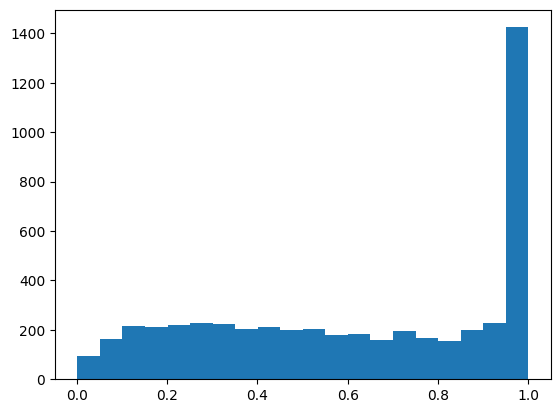

In [247]:
plt.hist(probs[:, 1], bins=20)

In [248]:
deuterons['prob'] = probs[:, 1].numpy()

In [249]:
d = deuterons[deuterons['prob'] >= 0.95]; print(len(d))
p = deuterons[deuterons['prob'] < 0.95]

1425


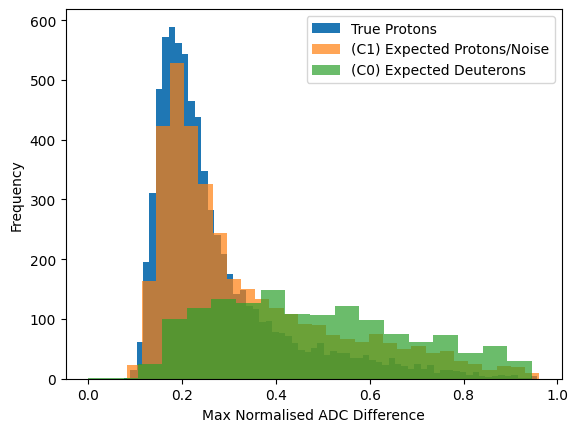

In [250]:
plt.hist(protons['maxdiff'], bins='auto', alpha=1, label='True Protons')
plt.hist(p['maxdiff'], bins='auto', alpha=0.7, label='(C1) Expected Protons/Noise')
plt.hist(d['maxdiff'], bins='auto', alpha=0.7, label='(C0) Expected Deuterons')
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()
plt.show()

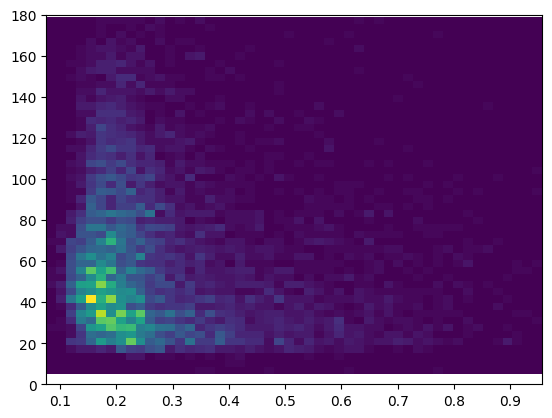

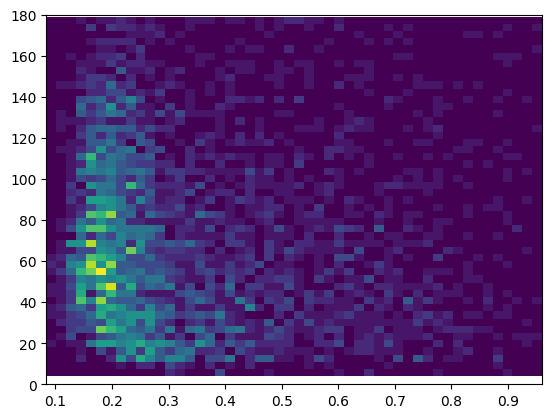

/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_33673/2766581428.py:11: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_33673/2766581428.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


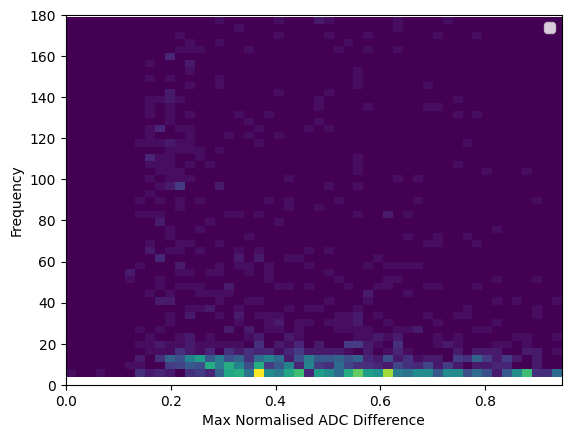

In [258]:
plt.hist2d(protons['maxdiff'].values, protons['height'].values, bins=50, alpha=1, label='True Protons')
plt.ylim(0, 180)
plt.show()
plt.hist2d(p['maxdiff'], p['height'], bins=50, alpha=1, label='(C1) Expected Protons/Noise')
plt.ylim(0, 180)
plt.show()
plt.hist2d(d['maxdiff'], d['height'], bins=50, alpha=1, label='(C0) Expected Deuterons')
plt.ylim(0, 180)
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# TODO: HOW TO NOT OVERFIT?
# TODO: HOW TO EVALUATE THE CLUSTERING? 